In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
# Typical chant for matplotlib

In [2]:
# Load the data
from pathlib import Path
from rsys_toolbox.io.eval_manager import load

DATA_PATH = Path(r'C:\Users\plasora1\Code\rsys-analyser\assets\20260512-MIAOpt-SimData_FullMIA.csv')
data = load(DATA_PATH)

In [3]:
from datetime import timedelta
TOLERANCE = timedelta(minutes=5) # We want T5 (why not?)

from rsys_toolbox.analysis import punctuality

# Compute punctuality for every station
punctuality_data = punctuality(data, tolerance=TOLERANCE) \
    .sort("punctuality", descending=False) # We sort by increasing punctuality...

# Identify the single worst station
worst_row = punctuality_data.row(0, named=True) # ... which means row[0] is now the worst in terms of punctuality
LOC_NAME = worst_row["Station name"]
TIPLOC = worst_row["Station abbreviation"]
punctuality_number = worst_row["punctuality"]

print(f'TIPLOC {TIPLOC!r} ({LOC_NAME}) has the worst punctuality of all the the TIPLOCs: {punctuality_number*100.:.2f} %')

TIPLOC 'BOL637' (Bolton sig637) has the worst punctuality of all the the TIPLOCs: 78.41 %


In [4]:
# If we want, we can also print punctuality data
print(punctuality_data)

# Could also save it to CSV
punctuality_data.write_csv('punctuality_data_by_tiploc.csv')

shape: (586, 3)
┌─────────────────────────────────┬──────────────────────┬─────────────┐
│ Station name                    ┆ Station abbreviation ┆ punctuality │
│ ---                             ┆ ---                  ┆ ---         │
│ str                             ┆ str                  ┆ f32         │
╞═════════════════════════════════╪══════════════════════╪═════════════╡
│ Bolton sig637                   ┆ BOL637               ┆ 0.784137    │
│ Manchester Airport              ┆ MNCRIAP              ┆ 0.794774    │
│ Heald Green West Jn             ┆ HLDGWJ               ┆ 0.80395     │
│ Heald Green North Jn            ┆ HLDGNJ               ┆ 0.811592    │
│ Attleborough South Junction     ┆ ATLBRJN              ┆ 0.814508    │
│ Chorley                         ┆ CHORLEY              ┆ 0.832316    │
│ BIRCHWOOD                       ┆ BIRCHWD              ┆ 0.833861    │
│ Heald Green                     ┆ HLDG                 ┆ 0.834508    │
│ Gatley                          ┆

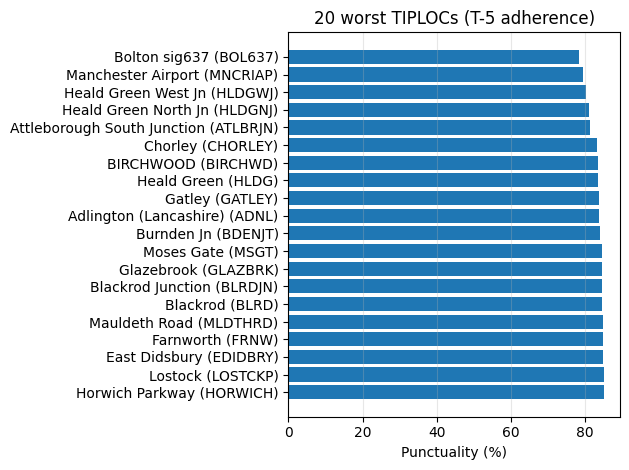

In [5]:
# Let's plot the worst 20 TIPLOCs
worst_n = punctuality_data.head(20)

# I want to display: "station (tiploc)"
labels = [f'{n} ({t})' for n, t in zip(worst_n.get_column("Station name").to_list(), worst_n.get_column("Station abbreviation").to_list())]

# Display percentages
values = [value * 100 for value in worst_n.get_column("punctuality").to_list()]

y_pos = range(len(labels)) # [0,1,2,...19]
fig, ax = plt.subplots()

# create a horizontal bar plot. values are our percentages, and y_pos the index of the station
ax.barh(list(y_pos), values)
ax.set_yticks(list(y_pos)) # One tick per station
ax.set_yticklabels(labels) # give our bars a name
ax.set_xlabel("Punctuality (%)")
ax.set_title("20 worst TIPLOCs (T-5 adherence)")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()  # worst at the top
plt.tight_layout()

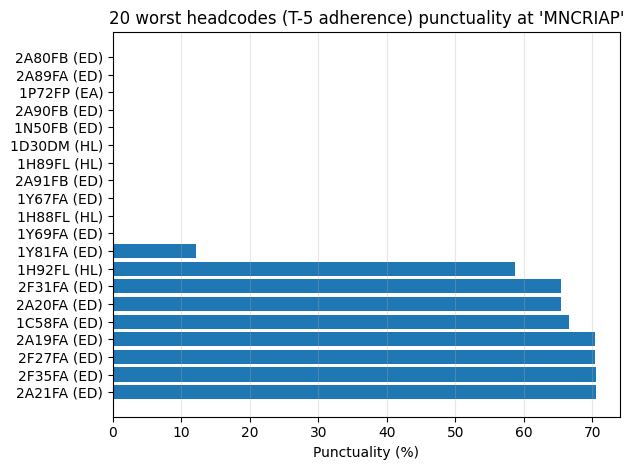

In [6]:
# All right, MNCRIAP isn't great, let's have a look at the trains there
BAD_TIPLOC = 'MNCRIAP'

from rsys_toolbox.core import LocationSelector

# Note, by default punctuality() will calculate a punctuality by station, you need to tell it what you want to breakdown by
# In here, you could choose other things too, like the "Operator Code", "Service Code", "Origin TIPLOC", "Destination TIPLOC", "Train class"...
train_punctuality_at_MNCRIAP = punctuality(
    data,
    tolerance=TOLERANCE,
    group_by=["Train name", "Operator Code"], # For now, we'll look at headcode/operator
    location_selector = LocationSelector(tiploc=BAD_TIPLOC) # I only want to see the arrivals at Manchester Airport
).sort("punctuality", descending=False)

# Again, we'll plot the 20 worst trains
worst_n = train_punctuality_at_MNCRIAP.head(20)

# I want to display: "headcode (operator)"
labels = [f'{h} ({o})' for h, o in zip(worst_n.get_column("Train name").to_list(), worst_n.get_column("Operator Code").to_list())]

# Display percentages
values = [value * 100 for value in worst_n.get_column("punctuality").to_list()]

y_pos = range(len(labels)) # [0,1,2,...19]
fig, ax = plt.subplots()

# create a horizontal bar plot. values are our percentages, and y_pos the index of the station
ax.barh(list(y_pos), values)
ax.set_yticks(list(y_pos)) # One tick per station
ax.set_yticklabels(labels) # give our bars a name
ax.set_xlabel("Punctuality (%)")
ax.set_title(f"20 worst headcodes (T-5 adherence) punctuality at {BAD_TIPLOC!r}")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()  # worst at the top
plt.tight_layout()

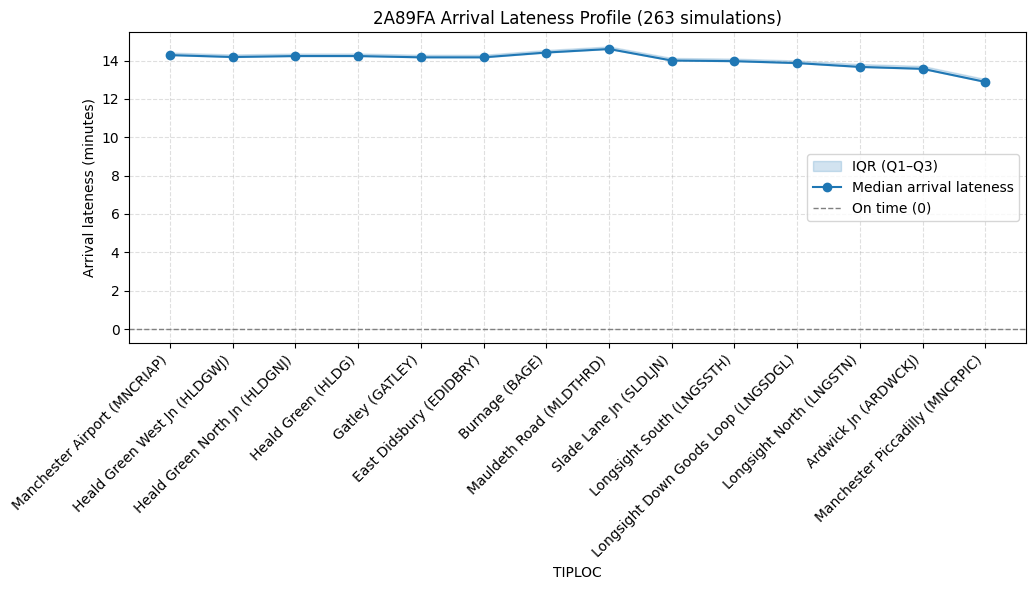

In [7]:
# All right, 2A89FA is bad let's drill down
BAD_HEADCODE = "2A89FA"

from rsys_toolbox.core import TrainSelector
from rsys_toolbox.plots import plot_median_lateness_profile

fig3 = plot_median_lateness_profile(data, train_selector=TrainSelector(headcode=BAD_HEADCODE))


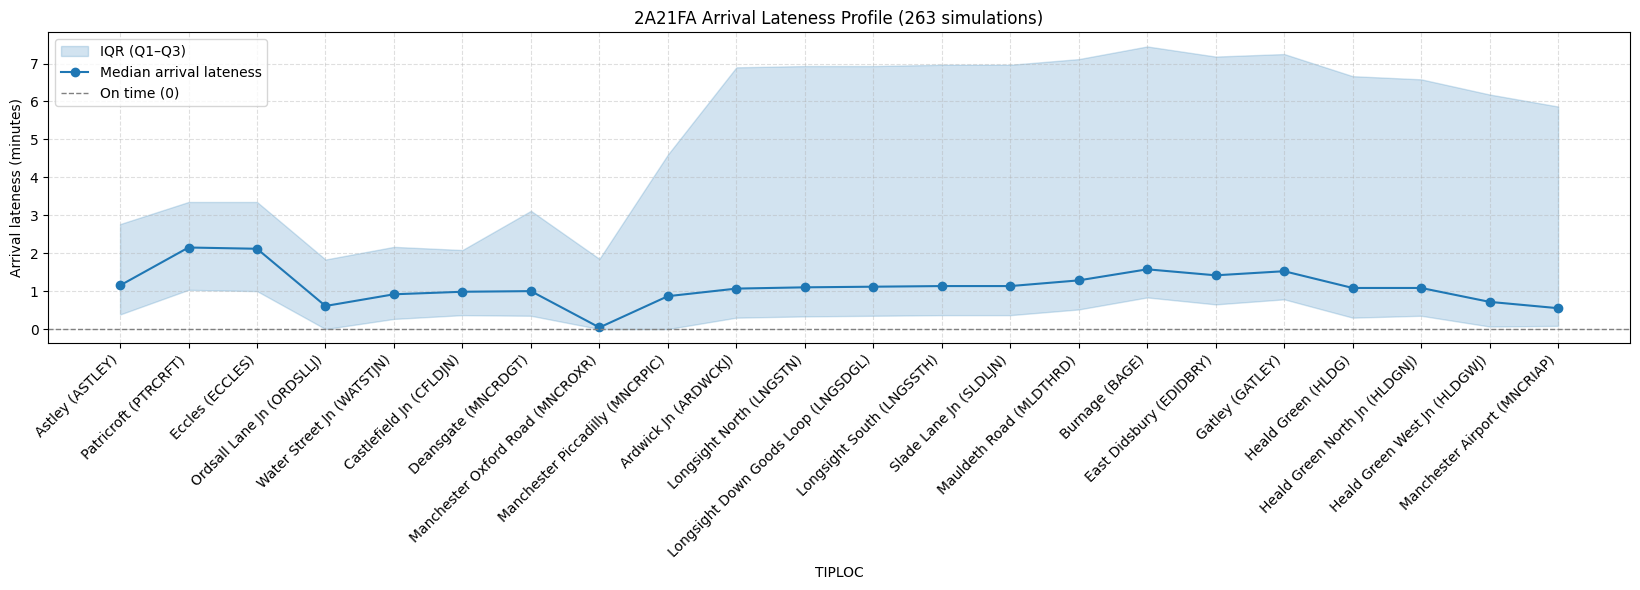

In [ ]:
# Let's look at a better one... 2A21FA
BAD_HEADCODE = "2A21FA"

from rsys_toolbox.core import TrainSelector
from rsys_toolbox.plots import plot_median_lateness_profile

fig3 = plot_median_lateness_profile(data, train_selector=TrainSelector(headcode=BAD_HEADCODE))

Output()

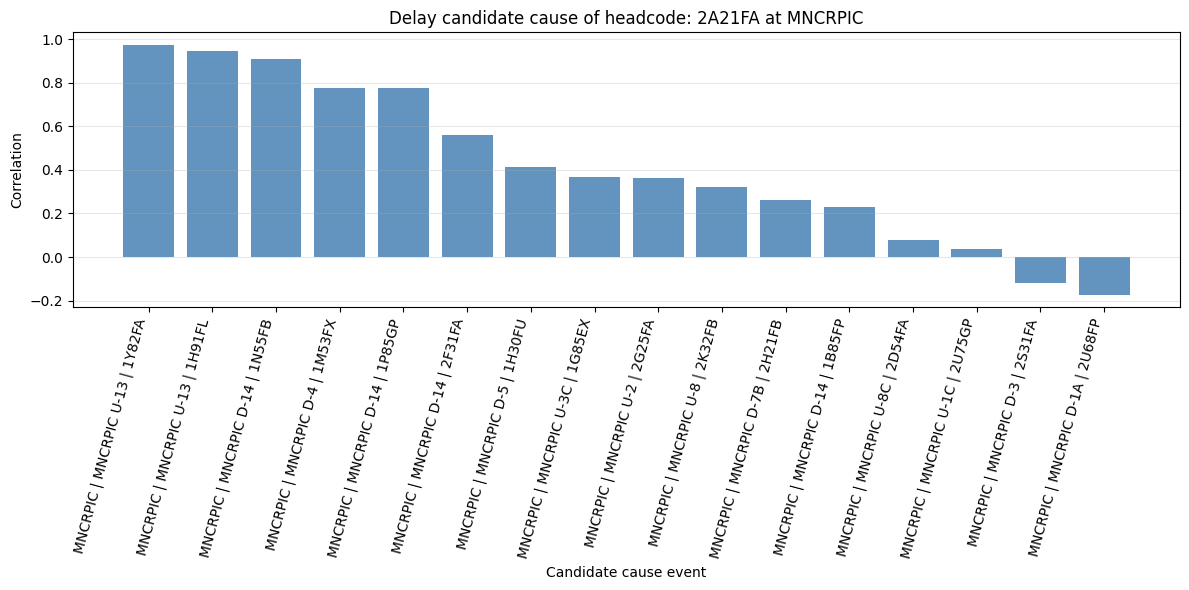

In [12]:
# Interesting! something is clearly happening at Manchester Piccadilly!
# Lets see, is there a train blocking ours?
BAD_TIPLOC = 'MNCRPIC'
from rsys_toolbox.analysis import correlation_search
import polars as pl

# In here we are searching for correlation between events
csearch = correlation_search(
    data,
    location_effect_hypothesis=LocationSelector(tiploc=BAD_TIPLOC), # My train that is delayed
    train_effect_hypothesis=TrainSelector(headcode=BAD_HEADCODE), # At Manchester Piccadilly
    location_cause_hypothesis=LocationSelector(tiploc=BAD_TIPLOC), # Are there train at Manchester Piccadilly that are also late
    max_cause_window=timedelta(minutes=5), # Less than 5 min before my trains?
)

corr_bars = (
    csearch
    .filter(pl.col("correlation").is_not_null())
    .filter(pl.col("pair_count") > 10)
    .sort("correlation", descending=True)
    .with_columns(
        pl.format(
            "{} | {} | {}",
            pl.col("Station abbreviation"),
            pl.col("Scheduled track"),
            pl.col("Train name"),
        ).alias("cause_label"),
    )
)

labels = corr_bars.get_column("cause_label").to_list()
values = corr_bars.get_column("correlation").to_list()
x = range(len(labels))

plt.figure(figsize=(12, 6))
plt.bar(x, values, color="steelblue", alpha=0.85)
plt.xlabel("Candidate cause event")
plt.ylabel("Correlation")
plt.title(f"Delay candidate cause of headcode: {BAD_HEADCODE} at {BAD_TIPLOC}")
plt.xticks(x, labels, rotation=75, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

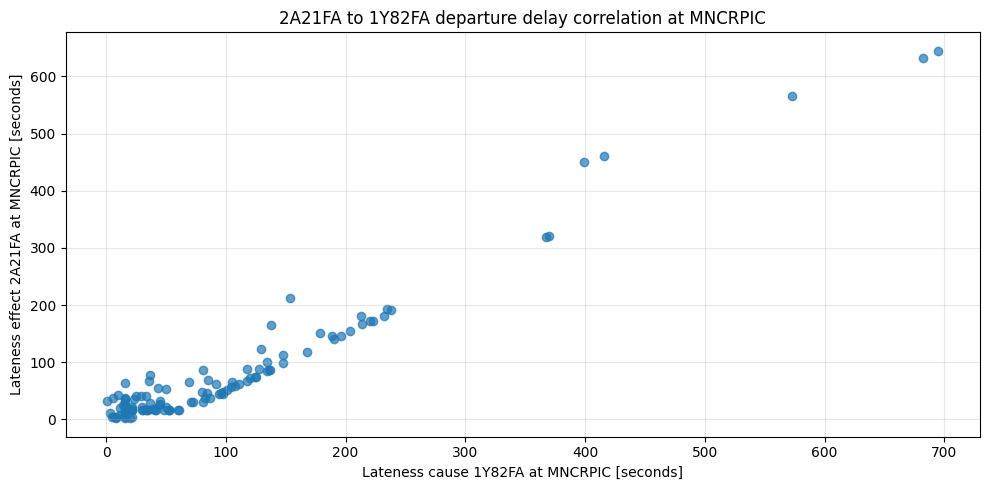

In [14]:
# This is saying: when 1Y82FA is late, 2A21FA is always late, same for 1H91FL. However, when 2U75GP is late, it doesn't look like 2A21FA is late. Let's check this
from rsys_toolbox.analysis import correlation
MAYBE_CAUSE = "1Y82FA"
result = correlation(
    data,
    location_cause_hypothesis=LocationSelector(tiploc=BAD_TIPLOC),
    location_effect_hypothesis=LocationSelector(tiploc=BAD_TIPLOC),
    train_cause_hypothesis=TrainSelector(headcode=MAYBE_CAUSE), # The possible cause is 1Y82FA
    train_effect_hypothesis=TrainSelector(headcode=BAD_HEADCODE),
    max_cause_window=timedelta(minutes=5),
)
plot_df = result.with_columns(
    (pl.col("Actual departure_cause") - pl.col("SchedDep_cause")).dt.total_seconds().alias("lateness_cause"),
    (pl.col("Actual departure_effect") - pl.col("SchedDep_effect")).dt.total_seconds().alias("lateness_effect"),
).filter((pl.col("lateness_cause") > 0) & (pl.col("lateness_effect") > 0))

plt.figure(figsize=(10, 5))

plt.scatter(plot_df.get_column("lateness_cause").to_list(), plot_df.get_column("lateness_effect").to_list(), alpha=0.7)
plt.xlabel(f"Lateness cause {MAYBE_CAUSE} at {BAD_TIPLOC} [seconds]")
plt.ylabel(f"Lateness effect {BAD_HEADCODE} at {BAD_TIPLOC} [seconds]")
plt.title(f"{BAD_HEADCODE} to {MAYBE_CAUSE} departure delay correlation at {BAD_TIPLOC}")
plt.grid(True, alpha=0.3)
plt.tight_layout()

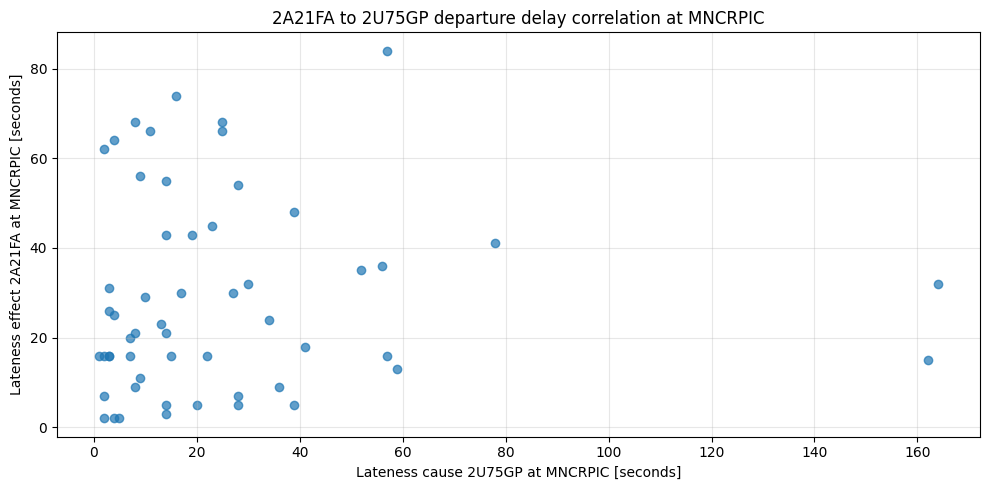

In [16]:
# Let's check the one that isn't the likely cause: 2U75GP

from rsys_toolbox.analysis import correlation
MAYBE_CAUSE = "2U75GP"
result = correlation(
    data,
    location_cause_hypothesis=LocationSelector(tiploc=BAD_TIPLOC),
    location_effect_hypothesis=LocationSelector(tiploc=BAD_TIPLOC),
    train_cause_hypothesis=TrainSelector(headcode=MAYBE_CAUSE), # The possible cause is 1Y82FA
    train_effect_hypothesis=TrainSelector(headcode=BAD_HEADCODE),
    max_cause_window=timedelta(minutes=5),
)
plot_df = result.with_columns(
    (pl.col("Actual departure_cause") - pl.col("SchedDep_cause")).dt.total_seconds().alias("lateness_cause"),
    (pl.col("Actual departure_effect") - pl.col("SchedDep_effect")).dt.total_seconds().alias("lateness_effect"),
).filter((pl.col("lateness_cause") > 0) & (pl.col("lateness_effect") > 0))

plt.figure(figsize=(10, 5))

plt.scatter(plot_df.get_column("lateness_cause").to_list(), plot_df.get_column("lateness_effect").to_list(), alpha=0.7)
plt.xlabel(f"Lateness cause {MAYBE_CAUSE} at {BAD_TIPLOC} [seconds]")
plt.ylabel(f"Lateness effect {BAD_HEADCODE} at {BAD_TIPLOC} [seconds]")
plt.title(f"{BAD_HEADCODE} to {MAYBE_CAUSE} departure delay correlation at {BAD_TIPLOC}")
plt.grid(True, alpha=0.3)
plt.tight_layout()